In [101]:
# importing libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.optimize import minimize


### Part (c)

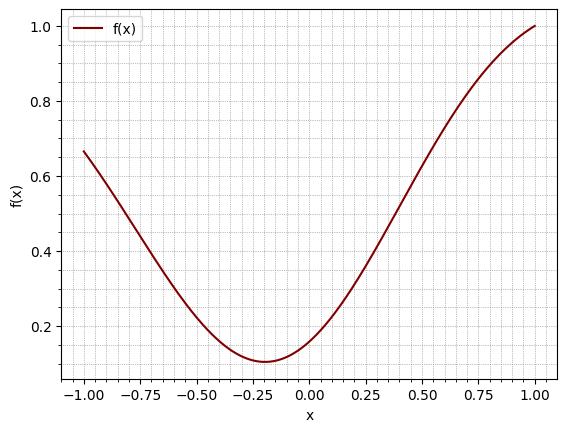

In [102]:
def f(x):
    return np.exp(-x**2)*np.sin(x-1) + 1

# plotting the function
x = np.linspace(-1,1,400)
plt.plot(x, f(x),color='maroon',label='f(x)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.minorticks_on()
plt.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray')
plt.legend()
plt.show()

In [103]:
def legendre_polynomial(n, x):
    if n == 0:
        return 1
    elif n == 1:
        return x
    elif n == 2:
        return 0.5 * (3*x**2 - 1)
    elif n == 3:
        return 0.5 * (5*x**3 - 3*x)
    elif n == 4:
        return (1/8.0) * (35*x**4 - 30*x**2 + 3)
    else:
        return ((2*n - 1) * x * legendre_polynomial(n-1, x) - (n - 1) * legendre_polynomial(n-2, x)) / n


# function to calculate coefficients
def coefficients(n, x, f):
    # Define the integrand as a function of x
    def integrand(x):
        return f(x) * legendre_polynomial(n, x)
    
    # Perform the integration over the interval [-1, 1]
    I, _ = quad(integrand, -1, 1)
    
    return ((2*n+1)/2.0) * I
    
# function to print the coefficients    
def print_coefficients(max_n, f):
    for n in range(max_n+1):
        c = coefficients(n, x, f)
        print(f"Coefficient c{n}: {c}")
        
print_coefficients(4, f)        

Coefficient c0: 0.44784831278662507
Coefficient c1: 0.28091490992363866
Coefficient c2: 0.4838938841641618
Coefficient c3: -0.13645674773391614
Coefficient c4: -0.11273025713192437


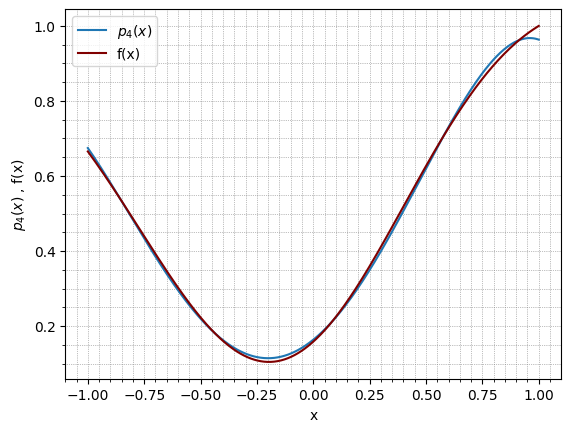

In [104]:
def construct_Pn(n, f):
    # Compute the coefficients c_i for i in range(n+1)
    coeffs = [coefficients(i, x, f) for i in range(n+1)]
    
    # Define the polynomial function Pn(x)
    def Pn(x):
        return sum(c * legendre_polynomial(i, x) for i, c in enumerate(coeffs))
    
    return Pn

# Construct P4(x) 
Pn_function = construct_Pn(4, f)

# Generate x values and compute P4(x) values
x_values = np.linspace(-1, 1, 400)
Pn_values = [Pn_function(x) for x in x_values]

# Plot P4(x)
plt.plot(x_values, Pn_values, label="$p_4(x)$")
plt.plot(x, f(x),color='maroon',label='f(x)')
plt.xlabel('x')
plt.ylabel('$p_4(x)$ , f(x)')
plt.xlabel('x')
plt.legend()
plt.minorticks_on()
plt.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray')
plt.show()

### Part (d)

In [105]:
# Define the objective function W
def objective_function(c):
    n = len(c)
    integral_terms = np.zeros(n)
    for i in range(n):
        terms = np.array([c[j] * legendre_polynomial(j, x) for j in range(n)])  # Convert to array
        integral_terms[i] = np.trapz(f(x) - np.sum(terms, axis=0), x) ** 2
    return np.sum(integral_terms)

# Define the gradient of the objective function
def gradient(c):
    n = len(c)
    grad = np.zeros(n)
    for i in range(n):
        integral_term = np.trapz(f(x) * legendre_polynomial(i, x), x) - 2 * c[i] / (2 * i + 1)
        grad[i] = -2 * integral_term
    return grad

# Define the approximated function using the optimized coefficients
def approximated_f(x, c):
    n = len(c)
    approx_f = np.sum([c[i] * legendre_polynomial(i, x) for i in range(n)], axis=0)
    return approx_f

# Domain for plotting
x = np.linspace(-1, 1, 100)

# Initial guess for coefficients c_i
max_n = 4
initial_guess = np.zeros(max_n+1)  # Adjust the size as per the number of Legendre polynomials you are using

# Minimize W using gradients
result = minimize(objective_function, initial_guess, jac=gradient, method='BFGS')

# Extract the optimized coefficients
optimal_c = result.x
print("=================================")
print("Optimized coefficients:")
print("=================================")
for n in range(max_n+1):
    print(f"c{n}: {optimal_c[n]}")
print("=================================")



Optimized coefficients:
c0: 0.4478686737695029
c1: 0.2809144444406612
c2: 0.4844153372676482
c3: -0.13626722666974048
c4: -0.10999294494482652


/tmp/ipykernel_938495/2933468185.py:6: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  terms = np.array([c[j] * legendre_polynomial(j, x) for j in range(n)])  # Convert to array


/home/mt22t/.local/lib/python3.8/site-packages/numpy/core/fromnumeric.py:86: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


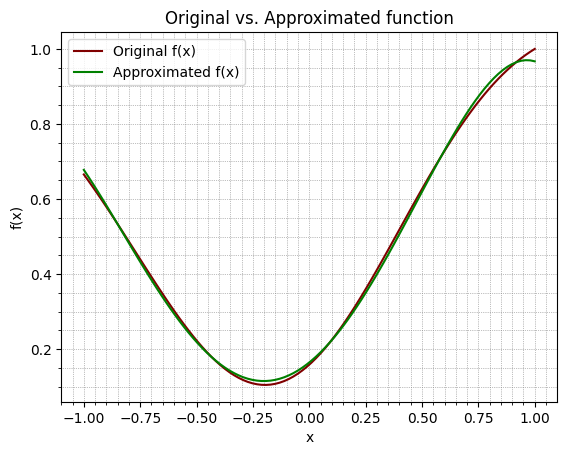

In [106]:
# Plot original and approximated functions
plt.plot(x, f(x), label='Original f(x)', color='maroon')
plt.plot(x, approximated_f(x, optimal_c), label='Approximated f(x)', color='green')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Original vs. Approximated function')
plt.legend()
plt.minorticks_on()
plt.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray')
plt.show()

### Part (e)